## Preparação 

In [229]:
# importar as bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import xgboost as xgb

from IPython.display import display

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor

In [230]:
# ler o arquivo e extrair as informações iniciais

try:
    data = pd.read_csv('taxi.csv')
    print(f"✅ Sucesso! Arquivo lido corretamente")
    print('-' * 50)
    print('🔍 Visualização das Primeiras Linhas do DataFrame')
    print('-' * 50)
    display(data.head())
    print('-' * 50)
    print('ℹ️ Informações Gerais do DataFrame')
    print('-' * 50)
    print(data.info())
    print('-' * 50)
    print('📊 Características Descritivas do DataFrame')
    print('-' * 50)
    display(data.describe())
    print('-' * 50)
    print('📐 Dimensões do DataFrame')
    print('-' * 50)
    print(data.shape)
except Exception as e:
    print(f"❌ Erro na leitura do arquivo. Erro: {e}")

✅ Sucesso! Arquivo lido corretamente
--------------------------------------------------
🔍 Visualização das Primeiras Linhas do DataFrame
--------------------------------------------------


,datetime,num_orders
0,2018-03-01 00:00:00,9
1,2018-03-01 00:10:00,14
2,2018-03-01 00:20:00,28
3,2018-03-01 00:30:00,20
4,2018-03-01 00:40:00,32


--------------------------------------------------
ℹ️ Informações Gerais do DataFrame
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26496 entries, 0 to 26495
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   datetime    26496 non-null  object
 1   num_orders  26496 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 414.1+ KB
None
--------------------------------------------------
📊 Características Descritivas do DataFrame
--------------------------------------------------


,num_orders
count,26496.000000
mean,14.070463
std,9.211330
min,0.000000
25%,8.000000
50%,13.000000
75%,19.000000
max,119.000000


--------------------------------------------------
📐 Dimensões do DataFrame
--------------------------------------------------
(26496, 2)


In [231]:
# analisar valores ausentes
ausentes = data['num_orders'].isnull().sum()
print(f"Há {ausentes} valores ausentes no dataset.")

Há 0 valores ausentes no dataset.


In [232]:
# 'datetime' : transformar tipo de dados object para datetime 
data['datetime'] = pd.to_datetime(data['datetime'])

In [233]:
# 'datetime': indexar e ordenar cronologicamente para trabalhar melhor com séries temporais
data = data.set_index('datetime').sort_index(ascending=True)

In [234]:
# separação da amostragem dos dados por hora
data = data.resample('h').sum()

In [235]:
# confirmação das alterações
print("Tipo do índice:", type(data.index))
print("Tipo dos dados do índice:", data.index.dtype)
print("Primeiras 3 linhas:")
display(data.head(3))

Tipo do índice: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Tipo dos dados do índice: datetime64[ns]
Primeiras 3 linhas:


,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71


In [236]:
# verificação do período contemplado pelo dataset
print(data.index.min(), data.index.max())

2018-03-01 00:00:00 2018-08-31 23:00:00


**Conclusões iniciais**

- **Tipo de Dados**: a coluna 'datetime' foi indexada e o tipo de dados alterado de object para datetime.
- **Nome das Colunas e Valores Ausentes**: nomenclatura adequada e não há valores ausentes.
- **Análise Descritiva**: vamor máximo 119 vs Q3 19, sugerindo presença de outliers extremos. Média 14 vs Std 9, o que reforça a tese da presença de outliers.
- **Amostragem**: definição da amostragem por hora.
- **Período**: período contemplado no dataset - 01/03/2018 00:00:00 até 31/08/2018 23:00:00.

In [237]:
# identificar outliers extremos

Q1 = data['num_orders'].quantile(0.25)
Q3 = data['num_orders'].quantile(0.75)

IQR = Q3 - Q1

outliers = data[(data['num_orders'] < Q1 - 1.5 * IQR) | (data['num_orders'] > Q3 + 1.5 * IQR)]

# representatividade de outliers no dataset (%)
percentual_outliers = len(outliers) / len(data)

# verificação da representatividade dos outliers
print(f"Número de outliers: {len(outliers)}")
print(f"Total de registros: {len(data)}")
print(f"Outliers correspondem a {percentual_outliers:.2%} do dataset")

Número de outliers: 121
Total de registros: 4416
Outliers correspondem a 2.74% do dataset


<Axes: title={'center': 'Chamadas para Taxi: Março à Agosto de 2018'}>

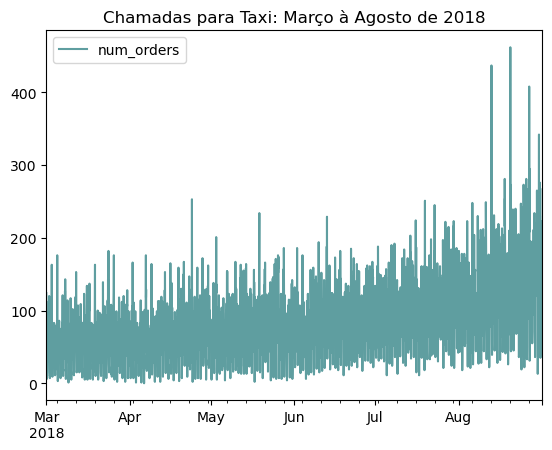

In [238]:
# plot do período completo do dataset
data.plot(
    title="Chamadas para Taxi: Março à Agosto de 2018",
    color='cadetblue',
    xlabel=''
)

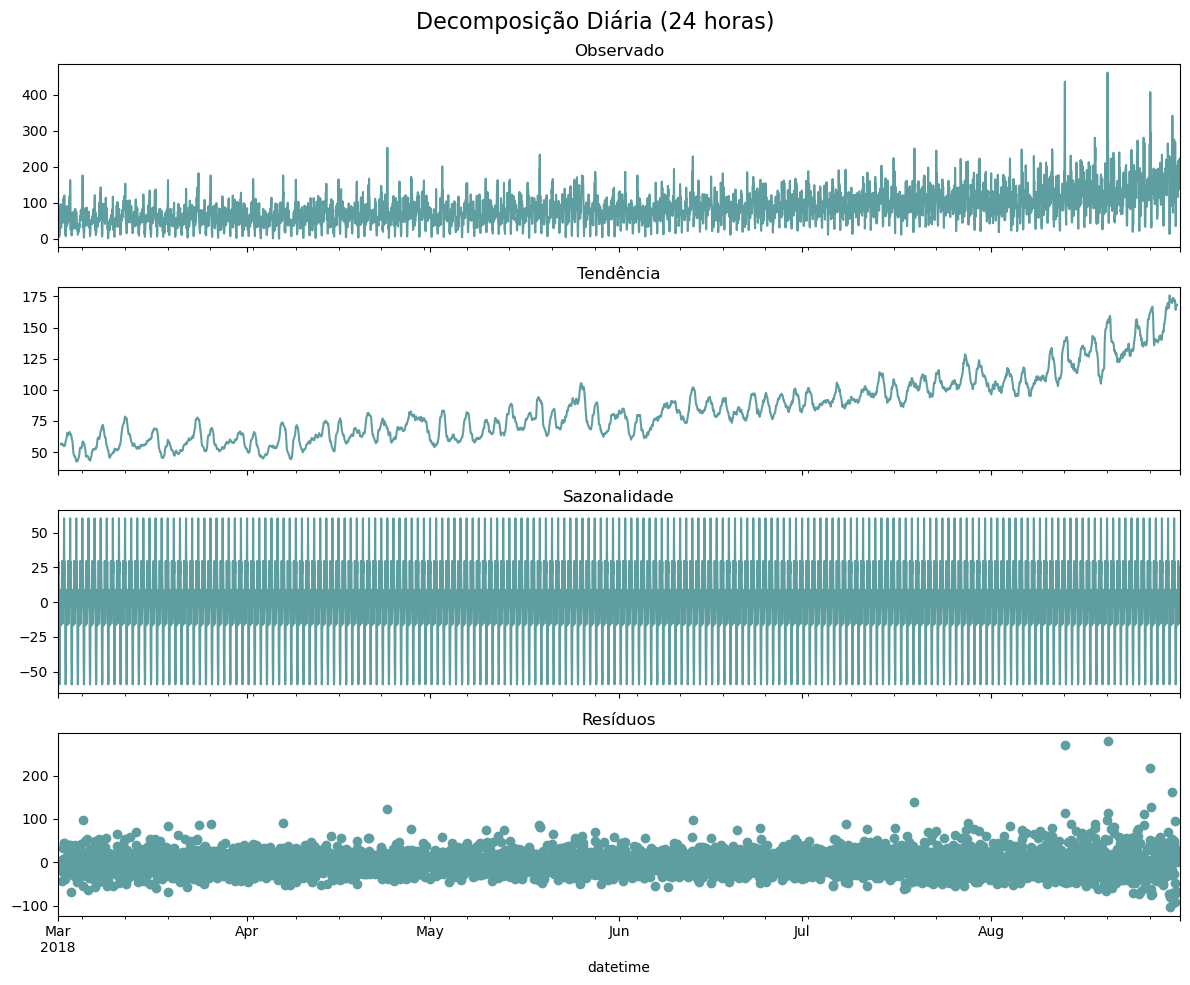

In [239]:
# decomposição do dataset para avaliar tendência e sazonalidade (modelo aditivo)
# período diário (24 horas)
data_decompose = seasonal_decompose(data, model='additive', period=24) 

# subplots personalizados
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
plt.suptitle('Decomposição Diária (24 horas)', fontsize=16, y=0.98)

data_decompose.observed.plot(ax=ax1, title='Observado', color='cadetblue')
data_decompose.trend.plot(ax=ax2, title='Tendência', color='cadetblue')
data_decompose.seasonal.plot(ax=ax3, title='Sazonalidade', color='cadetblue')
data_decompose.resid.plot(ax=ax4, title='Resíduos', color='cadetblue', style='o')

plt.tight_layout()
plt.show()

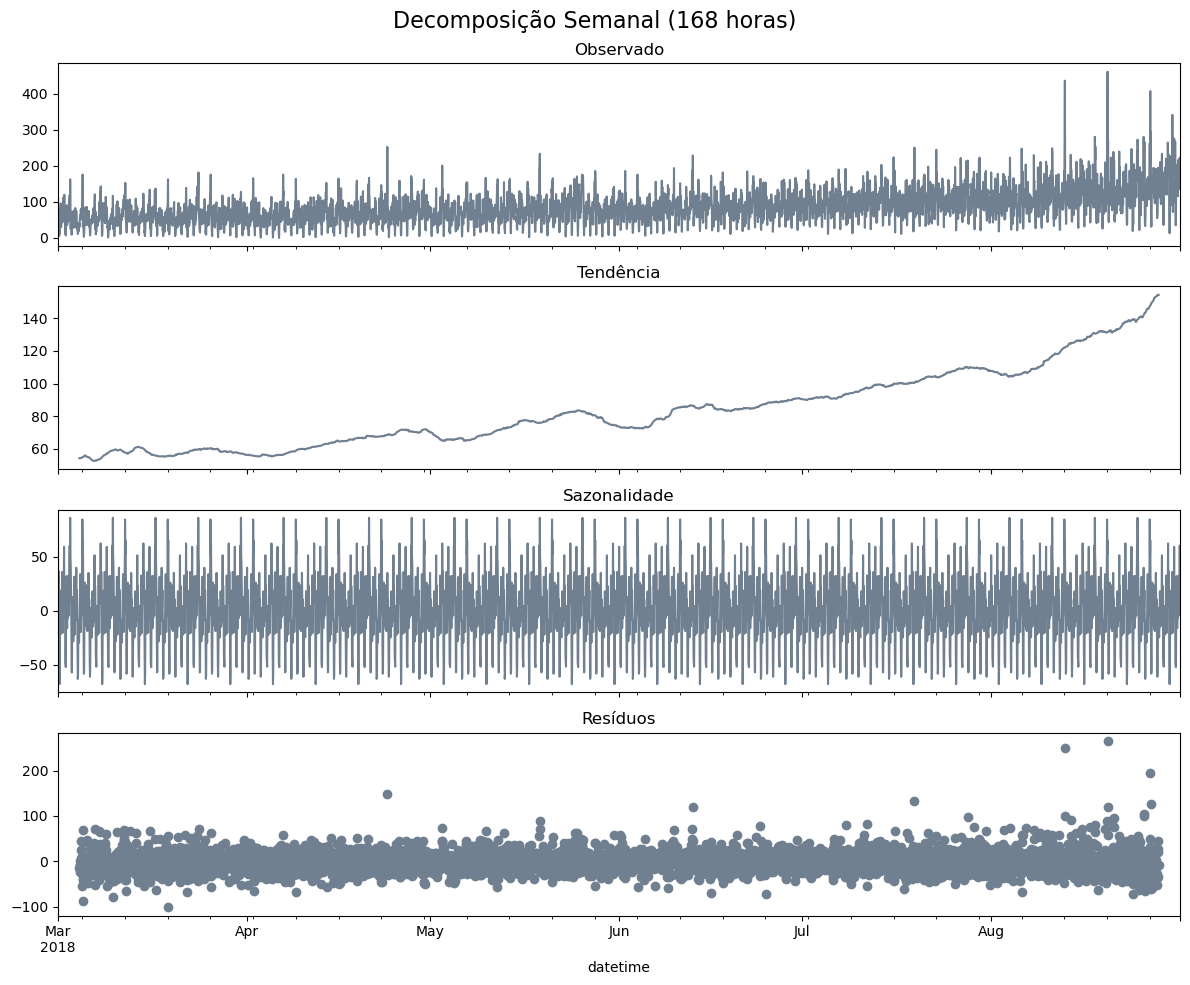

In [240]:
# decomposição do dataset para avaliar tendência e sazonalidade
# período semanal (7 dias x 24 horas = 168 horas)
data_decompose = seasonal_decompose(data, model='additive', period=168) 

# subplots personalizados
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
plt.suptitle('Decomposição Semanal (168 horas)', fontsize=16, y=0.98)

data_decompose.observed.plot(ax=ax1, title='Observado', color='slategray')
data_decompose.trend.plot(ax=ax2, title='Tendência', color='slategray')
data_decompose.seasonal.plot(ax=ax3, title='Sazonalidade', color='slategray')
data_decompose.resid.plot(ax=ax4, title='Resíduos', color='slategray', style='o')

plt.tight_layout()
plt.show()

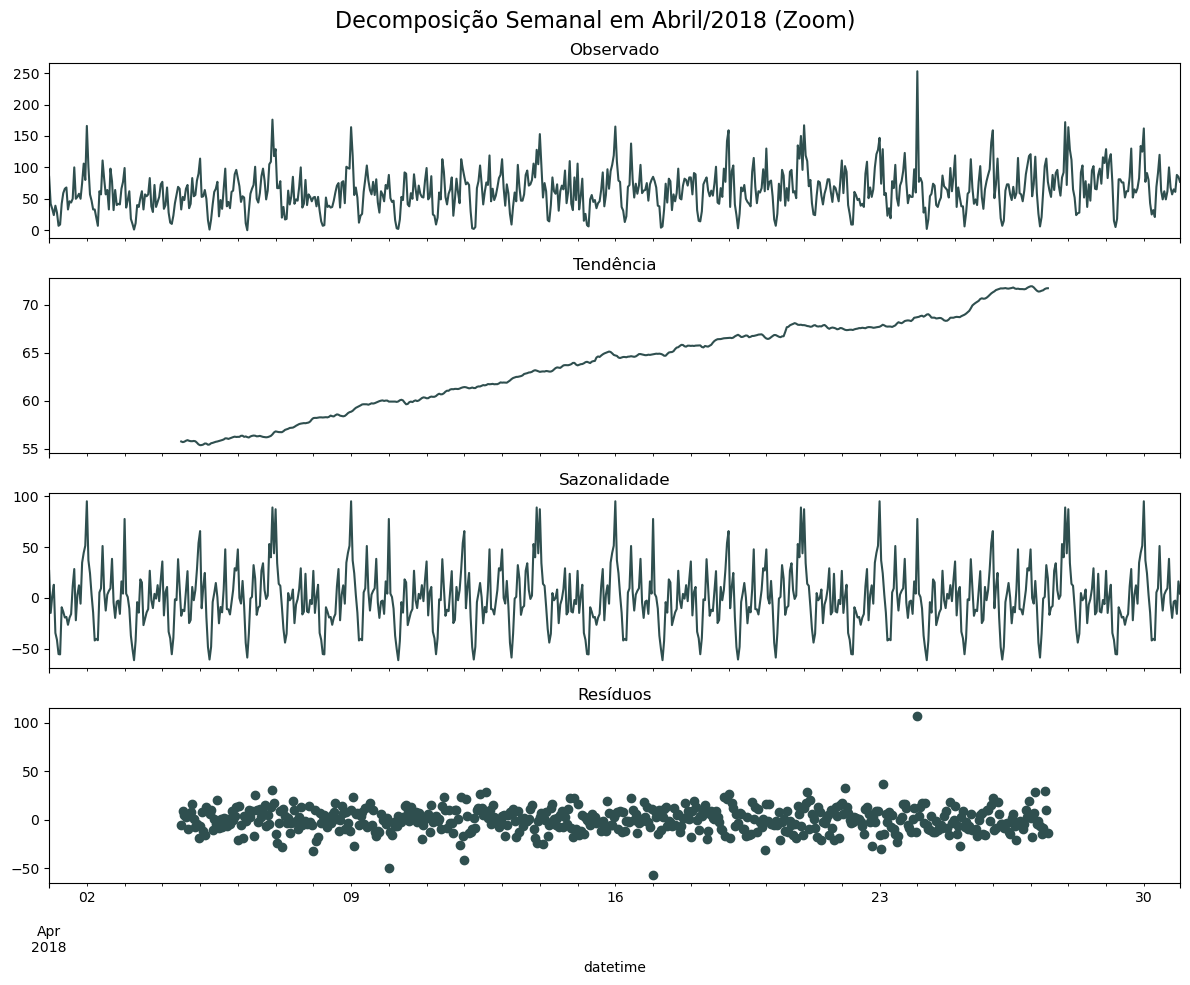

In [241]:
# "zoom" no período semanal para o período de abril

# dia 01/04/2018 foi um domingo
periodo_maio = data.loc['2018-04-01':'2018-04-30']

data_decompose = seasonal_decompose(periodo_maio, model='additive', period=168)

# subplots personalizados
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
plt.suptitle('Decomposição Semanal em Abril/2018 (Zoom)', fontsize=16, y=0.98)

data_decompose.observed.plot(ax=ax1, title='Observado', color='darkslategray')
data_decompose.trend.plot(ax=ax2, title='Tendência', color='darkslategray')
data_decompose.seasonal.plot(ax=ax3, title='Sazonalidade', color='darkslategray')
data_decompose.resid.plot(ax=ax4, title='Resíduos', color='darkslategray', style='o')

plt.tight_layout()
plt.show()

**Diagnóstico da Decomposição da Série Temporal**: modelo aditivo

📈 **Tendência (Trend)** - Aceleração de Demanda
- Comportamento: ascensão constante e discreta até junho, quando há uma mudança de inclinação perceptível. Até junho, a média flutuava abaixo de 100 chamados de taxi. Em agosto, a média ultrapassa 100 e atinge 150 chamados.
- Zoom no mês de abril: crescimento constante durante o mês, iniciando em 55 pedidos e finalizando acima de 70 (+27% em 30 dias).
- Modelo: modelo de precisão precisa lidar com uma série não estacionária.
- Hipótese de Negócio: presença de fatores sazonais (por exemplo: férias, feriados, eventos típicos para o período).

🗓️ **Sazonalidade (Seasonal)** - Microciclos Semanais
- Comportamento: padrão semanal identificado: 3 dias consecutivos de alta, 1 queda, 1 pico isolado. Analisando serviços de transporte urbano, sugere-se:
    - 3 dias de alta: rotina corporativa (Terça, Quarta e Quinta);
    - 1 queda: Segunda-feira (dia de ritmo mais lento pós-final de semana);
    - 1 pico isolado: Pode ser Sexta ou Sábado (lazer).

⚠️ **Resíduos (Resid)** - Instabilidade e Outliers
- Comportamento: aumento da variância em agosto (pontos mais espalhados) indica que o componente aleatório cresceu, sugerindo eventos atípicos.
- Ponto de atenção para treinamento do modelo, pois provavelmente terá mais dificuldade em prever agosto do que previu os meses anteriores.



## Análise

In [242]:
# criar features

def make_features(data, max_lag, rolling_mean_size):
    '''
    Função para criar novas features, 
    implementar características de defasagem (lag), e
    aplicar a média móvel
    '''
    data['year'] = data.index.year
    data['month'] = data.index.month
    data['day'] = data.index.day
    data['dayofweek'] = data.index.dayofweek
    data['hour'] = data.index.hour
    # final de semana (sábado e domingo)
    data['is_weekend'] = (data.index.dayofweek >= 5).astype(int)
    # horário comercial de 7h às 19h
    data['is_business_hours'] = ((data.index.hour >= 7) & (data.index.hour <= 19)).astype(int)
    
    for lag in range(1, max_lag + 1):
        data['lag_{}'.format(lag)] = data['num_orders'].shift(lag)

    data['rolling_mean'] = (data['num_orders'].shift().rolling(rolling_mean_size).mean())

# max_lag e rooling_mean_size definidos em 7 (padrão semanal identificado)
make_features(data, 7, 7)
display(data.head())

,num_orders,year,month,day,dayofweek,hour,is_weekend,is_business_hours,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,rolling_mean
datetime,,,,,,,,,,,,,,,,
2018-03-01 00:00:00,124,2018,3,1,3,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 01:00:00,85,2018,3,1,3,1,0,0,124.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 02:00:00,71,2018,3,1,3,2,0,0,85.0,124.0,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 03:00:00,66,2018,3,1,3,3,0,0,71.0,85.0,124.0,NaN,NaN,NaN,NaN,NaN
2018-03-01 04:00:00,43,2018,3,1,3,4,0,0,66.0,71.0,85.0,124.0,NaN,NaN,NaN,NaN


In [243]:
# estratégia de treinamento

estrategia = {
    'Pipeline': ['01', '02', '02', '02'],
    'Modelo': ['SARIMA', 'Linear Regression', 'Random Forest', 'XGBoost'],
    'Objetivo': ['Baseline Estatístico', 'Baseline Machine Learning', 'Captura Não-Linear', 'Alta Performance'],
    'Pré-Processamento': [
        'Lagged Features + Diferenciação + Teste ADF', 
        'Lagged Features + Diferenciação + OHE', 
        'Lagged Features', 
        'Lagged Features'
    ],
    'Normalização': ['Não', 'Sim', 'Não', 'Não'],
    'Estacionariedade': ['Diferenciação (d=1)', 'Diferenciação (d=1)', 'Não requer', 'Não requer']
}

resumo_estrategia = pd.DataFrame(estrategia)
display(resumo_estrategia)

,Pipeline,Modelo,Objetivo,Pré-Processamento,Normalização,Estacionariedade
0,01,SARIMA,Baseline Estatístico,Lagged Features + Diferenciação + Teste ADF,Não,Diferenciação (d=1)
1,02,Linear Regression,Baseline Machine Learning,Lagged Features + Diferenciação + OHE,Sim,Diferenciação (d=1)
2,02,Random Forest,Captura Não-Linear,Lagged Features,Não,Não requer
3,02,XGBoost,Alta Performance,Lagged Features,Não,Não requer


## Treinamento

### Pipeline 1: SARIMAX

In [244]:
# verificação da estacionariedade do dataset (Teste ADT) após a técnica de diferenciação (d=1)

def check_stationarity(timeseries):
    '''
    Função para checar a estacionariedade ou não de uma série temporal (Teste Dickey-Fuller)
    '''
    print('=' * 50)
    print('Resultados do Teste Dickey-Fuller (ADF):')
    print('=' * 50)

    # utilização do critério 'AIC' para escolher automaticamente a quantidade de lags
    data_test = adfuller(timeseries, autolag='AIC') 

    # utilização dos 4 primeiros valores da tupla data_test + criação de Series com os rótulos descritivos
    data_output = pd.Series(data_test[0:4], index=['Estatística Teste','p-value','Lags Utilizados','Número de Observações'])
    print(data_output)
    print('-' * 50)
    if data_test[1] <= 0.05:
        print("✅ Conclusão: A série é estacionária (rejeita H0)")
    else:
        print("❌ Conclusão: A série não é estacionária (não rejeita H0)")

# aplicação da diferenciação (d=1) - calcula a diferença entre valores consecutivos
data_diff = data['num_orders'].diff().dropna()

# novo teste para a série diferenciada
check_stationarity(data_diff)

Resultados do Teste Dickey-Fuller (ADF):
Estatística Teste       -1.579323e+01
p-value                  1.095878e-28
Lags Utilizados          3.100000e+01
Número de Observações    4.383000e+03
dtype: float64
--------------------------------------------------
✅ Conclusão: A série é estacionária (rejeita H0)


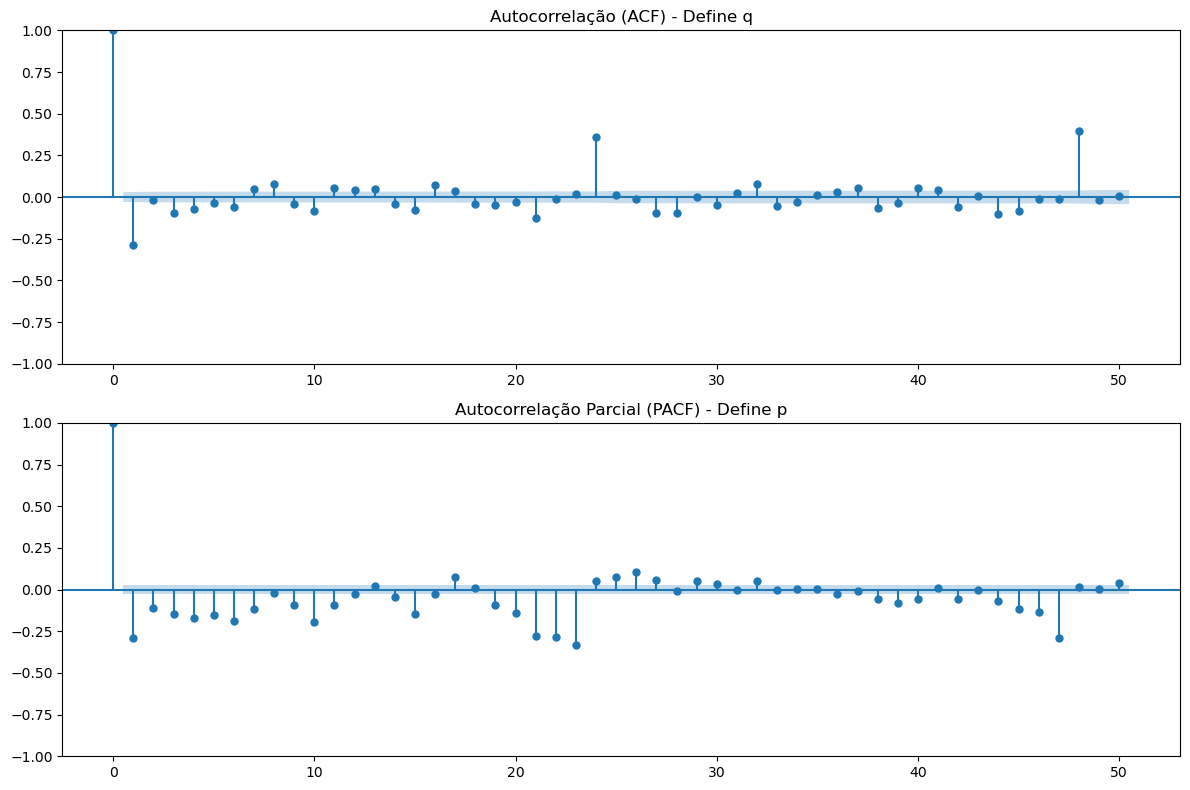

In [245]:
# plot dos gráficos ACF / PACF para verificar a média móvel (q) e os termos autoregressivos (p)

# configuração dos plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(data_diff, lags=50, ax=ax1, title='Autocorrelação (ACF) - Define q')
plot_pacf(data_diff, lags=50, ax=ax2, title='Autocorrelação Parcial (PACF) - Define p')

plt.tight_layout()
plt.show()

🚀 Treinando o Modelo SARIMA...
🎯 Avaliação do Modelo SARIMAX
 * REQM (RMSE): 44.49
 * MAPE: 37.74%
---------------------------------------------
✅ APROVADO! O modelo atingiu a meta REQM < 48.


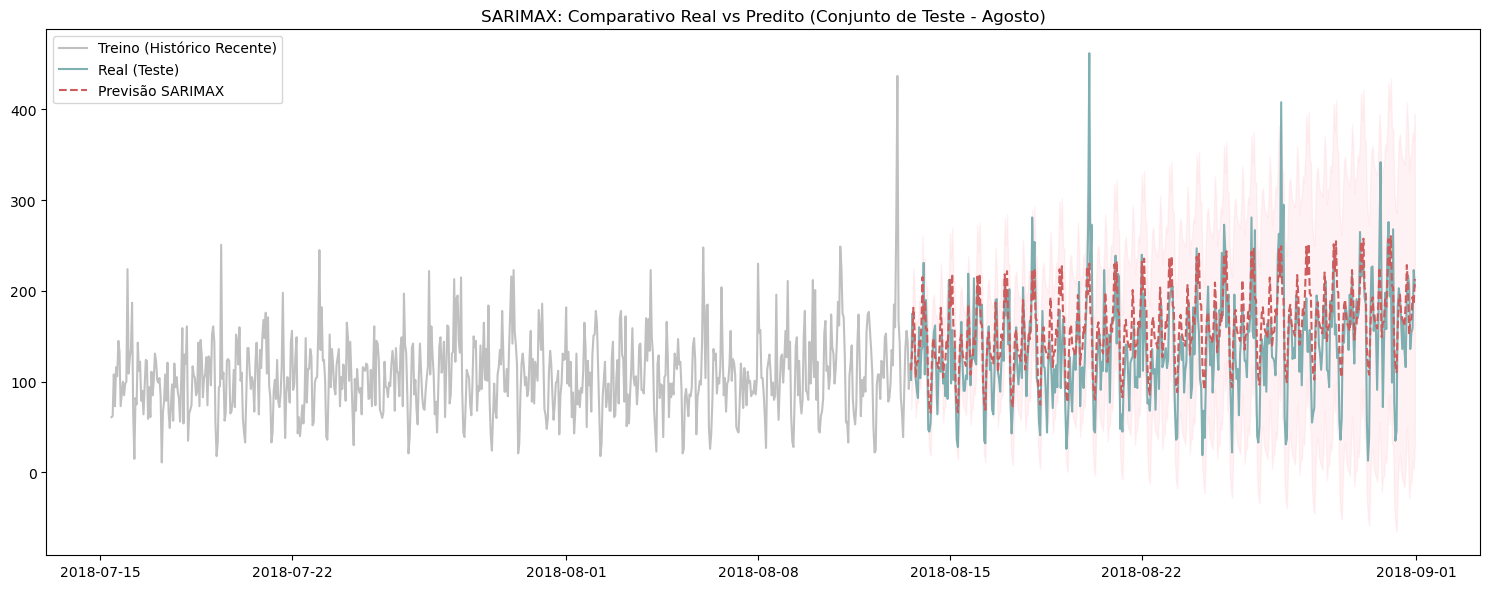

In [246]:
# divisão dos dados de treino e teste na proporção 90:10
data_sarima = data.copy()
train_size = int(len(data_sarima) * 0.9)
train = data_sarima.iloc[:train_size]
test = data_sarima.iloc[train_size:]


print(f"🚀 Treinando o Modelo SARIMA...")
print('=' * 45)

# treinamento do modelo
model_sarima = SARIMAX(train['num_orders'],
                       order=(1, 1, 1),               # parâmetros não sazonais - p(1), d(1), q(1)
                       seasonal_order=(1, 1, 1, 24),  # parâmetros sazonais - P(1), D(1), Q(1), s(24)   
                       enforce_stationarity=False,    # permissão de modelos não-estacionários
                       enforce_invertibility=False)   # permissão de modelos não-invertíveis

# disp=False - não exibe detalhes do treinamento
sarima_results = model_sarima.fit(disp=False)

# predições
forecast_steps = len(test)
forecast_obj = sarima_results.get_forecast(steps=forecast_steps)  # previsões + intervalos de confiança
mean_forecast = forecast_obj.predicted_mean                       # apenas valores previstos
mean_forecast.index = test.index                                  # índice temporal alinhado

# cálculo das métricas
sarima_rmse = np.sqrt(mean_squared_error(test['num_orders'], mean_forecast))
sarima_mape = mean_absolute_percentage_error(test['num_orders'], mean_forecast) * 100

print(f"🎯 Avaliação do Modelo SARIMAX")
print(f"{'=' * 45}")
print(f" * REQM (RMSE): {sarima_rmse:.2f}")
print(f" * MAPE: {sarima_mape:.2f}%")
print(f"{'-' * 45}")

# aprovação do modelo
if sarima_rmse < 48:
    print(f"✅ APROVADO! O modelo atingiu a meta REQM < 48.")
else:
    print(f"❌ REPROVADO! O modelo não atingiu a meta REQM < 48.")

# plot para visualização Real vs Predito
plt.figure(figsize=(15, 6))
plt.plot(train['num_orders'].tail(700), label='Treino (Histórico Recente)', color='silver')   # .tail(700) mostra os últimos pontos do conjunto de treino para não poluir o gráfico
plt.plot(test['num_orders'], label='Real (Teste)', color='cadetblue', alpha=0.8)              # configuração linha do conjunto de teste
plt.plot(mean_forecast, label='Previsão SARIMAX', color='indianred', linestyle='--')           # configuração da previsão sarima no gráfico

# banda de confiança
conf_int = forecast_obj.conf_int()          # conf_int() extrai uma tabela com 2 colunas (limite inferior e superior)
plt.fill_between(                           # fill_between() cria uma área sombreada no gráfico
                 test.index,                # eixo X = índice das datas do conjunto de teste
                 conf_int.iloc[:, 0],       # limite inferior
                 conf_int.iloc[:, 1],       # limite superior
                 color='pink', alpha=0.2)   # cor e intensidade

plt.title('SARIMAX: Comparativo Real vs Predito (Conjunto de Teste - Agosto)')
plt.legend()
plt.tight_layout()
plt.show()

**Conclusão Pipeline 1: SARIMAX**

- Dataset transformado em estacionária validado pelo Teste Dickey-Fuller (ADF).
- Gráficos ACF/PACF para identificar os melhores valorespara a média móvel (q) e os termos autoregressivos (p):
    - q(1): queda abrupta após o lag 1 no ACF
    - p(1): primeiro lag significativo no PACF
    - s(24): picos sazonais significativos nos lag 24 e 48, reforçando sazonalidade diária
- Métricas:
    - O modelo SARIMAX validou a estrutura sazonal da demanda, atingindo o objetivo de erro absoluto (REQM 44.49 < 48).
    - Contudo, a baixa performance relativa (MAPE 37%) sugere que o modelo subestima picos de alta volatilidade.

### Pipeline 2: Linear Regression + Random Forest + XG

In [247]:
# dataset dedicado para pipeline de LR
data_lr = data.copy()

print('=' * 50)
print(f"Dataset Pré-Processamento: Lag implementado")
print('=' * 50)
display(data_lr.head(3))

# diferenciação
data_lr['num_orders_diff'] = data_lr['num_orders'].diff()

# remoção dos valores NaN
data_lr = data_lr.dropna()

# OHE para as colunas 'hour' e 'dayofweek'
print('-' * 50)
print(f"Tratamento com OHE")
print(f" * Número de colunas antes: {data_lr.shape[1]}")
data_lr = pd.get_dummies(data_lr, columns=['hour', 'dayofweek'], drop_first=True)
print(f" * Número de colunas depois: {data_lr.shape[1]}")
print('-' * 50)


print('=' * 50)
print(f"Dataset Pós-Processamento: Diferenciação + OHE")
print('=' * 50)
pd.set_option('display.max_columns', None)
display(data_lr.head(3))

print('-' * 50)
print(f"Valores nulos pós tratamento (dropna): {data_lr.isnull().sum().sum()}")
print('-' * 50)

Dataset Pré-Processamento: Lag implementado


,num_orders,year,month,day,dayofweek,hour,is_weekend,is_business_hours,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,rolling_mean
datetime,,,,,,,,,,,,,,,,
2018-03-01 00:00:00,124,2018,3,1,3,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 01:00:00,85,2018,3,1,3,1,0,0,124.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 02:00:00,71,2018,3,1,3,2,0,0,85.0,124.0,NaN,NaN,NaN,NaN,NaN,NaN


--------------------------------------------------
Tratamento com OHE
 * Número de colunas antes: 17
 * Número de colunas depois: 44
--------------------------------------------------
Dataset Pós-Processamento: Diferenciação + OHE


,num_orders,year,month,day,is_weekend,is_business_hours,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,rolling_mean,num_orders_diff,hour_1,hour_2,hour_3,hour_4,hour_5,hour_6,hour_7,hour_8,hour_9,hour_10,hour_11,hour_12,hour_13,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23,dayofweek_1,dayofweek_2,dayofweek_3,dayofweek_4,dayofweek_5,dayofweek_6
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-03-01 07:00:00,15,2018,3,1,0,1,12.0,6.0,43.0,66.0,71.0,85.0,124.0,58.142857,3.0,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
2018-03-01 08:00:00,34,2018,3,1,0,1,15.0,12.0,6.0,43.0,66.0,71.0,85.0,42.571429,19.0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
2018-03-01 09:00:00,69,2018,3,1,0,1,34.0,15.0,12.0,6.0,43.0,66.0,71.0,35.285714,35.0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False


--------------------------------------------------
Valores nulos pós tratamento (dropna): 0
--------------------------------------------------


In [248]:
# divisão dos dados de treino e teste na proporção 90:10
train_size = int(len(data_lr) * 0.9)
X_train = data_lr.drop(['num_orders', 'num_orders_diff'], axis=1).iloc[:train_size]
X_test = data_lr.drop(['num_orders', 'num_orders_diff'], axis=1).iloc[train_size:]
y_train = data_lr['num_orders'].iloc[:train_size]
y_test = data_lr['num_orders'].iloc[train_size:]

# normalização
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [249]:
# criando função para treinar os modelos ML

def train_and_evaluate_model(model, model_name, X_train, X_test, y_train, y_test):
    """
    Função reprodutível para treinar e avaliar modelos de ML
    """
    print(f"{'=' * (len(model_name) + 40)}")
    print(f"🚀 Treinando o Modelo {model_name.upper()}...")
    print('-' * (len(model_name) + 40))

    # treinamento do modelo
    model.fit(X_train, y_train)

    # predições
    y_pred = model.predict(X_test)

    # métricas
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    # avaliação dos resultados
    print(f"🎯 Avaliação do Modelo {model_name.upper()}")
    print(f"{'-' * (len(model_name) + 40)}")
    print(f" * REQM (RMSE): {rmse:.2f}")
    print(f" * MAPE: {mape:.2f}%")
    print(f"{'-' * (len(model_name) + 40)}")

    # aprovação do modelo conforme exigências do projeto
    check_approval(rmse, model_name)

    return model, y_pred, rmse, mape

def check_approval(rmse, model_name):
    """
    Função para verificar aprovação do modelo
    """
    if rmse < 48:
        print(f"✅ APROVADO! O modelo atingiu a meta REQM < 48.")
    else:
        print(f"❌ REPROVADO! O modelo não atingiu a meta REQM < 48.")
    print()

In [250]:
# chamando sua função para Linear Regression
linear_model, y_pred_lin, rmse_lin, mape_lin = train_and_evaluate_model(
    LinearRegression(), 
    'Linear Regression', 
    X_train_scaled, X_test_scaled, y_train, y_test
)

🚀 Treinando o Modelo LINEAR REGRESSION...
---------------------------------------------------------
🎯 Avaliação do Modelo LINEAR REGRESSION
---------------------------------------------------------
 * REQM (RMSE): 45.21
 * MAPE: 27.01%
---------------------------------------------------------
✅ APROVADO! O modelo atingiu a meta REQM < 48.



**Conclusão: Modelo Regressão Linear**

- REQM: modelo aprovado conforme os pré requisistos do projeto (< 48), porém apresentou performance ligeiramente abaixo do SARIMAX (45.59 vs 44.49).
- MAPE: performance melhor comparada com SARIMAX (26.87 vs 37.74).

In [251]:
# chamando sua função para Random Forest
rf_model, y_pred_rf, rmse_rf, mape_rf = train_and_evaluate_model(
    RandomForestRegressor(
    n_estimators=100,
    random_state=42    
), 
    'Random Forest', 
    X_train, X_test, y_train, y_test
)

🚀 Treinando o Modelo RANDOM FOREST...
-----------------------------------------------------


🎯 Avaliação do Modelo RANDOM FOREST
-----------------------------------------------------
 * REQM (RMSE): 44.98
 * MAPE: 25.69%
-----------------------------------------------------
✅ APROVADO! O modelo atingiu a meta REQM < 48.



**Conclusão: Modelo Random Forest**

- REQM: modelo aprovado conforme os pré requisistos do projeto (< 48), porém SARIMAX mantém performance ligeiramente melhor do que os demais modelos (SARIMAX: 44.49).
- MAPE: performance melhor comparada com Linear Regression (25.69 vs 26.87).

In [252]:
# chamando sua função para XGBoost
xgb_model, y_pred_xgb, rmse_xgb, mape_xgb = train_and_evaluate_model(
    xgb.XGBRegressor(
    n_estimators=100,
    random_state=42
    ),
    'XGBoost', 
    X_train, X_test, y_train, y_test
)

🚀 Treinando o Modelo XGBOOST...
-----------------------------------------------
🎯 Avaliação do Modelo XGBOOST
-----------------------------------------------
 * REQM (RMSE): 45.70
 * MAPE: 26.99%
-----------------------------------------------
✅ APROVADO! O modelo atingiu a meta REQM < 48.



**Conclusão: Modelo XGBoost**

- REQM: modelo aprovado conforme os pré requisistos do projeto (< 48), porém tem pior performance comparada aos demais modelos. SARIMAX mantém melhor performance: 44.49.
- MAPE: modelo não conseguiu superar MAPE dos modelos anteriores. Melhor performance MAPE é de Random Forest (25.69).

## Conclusão do Projeto

In [253]:
resumo_executivo = {
    'Modelo': [
        'SARIMAX', 'Linear Regression', 'Random Forest', 'XGBoost'
    ],
    'REQM': [
        f"{sarima_rmse:.2f}",
        f"{rmse_lin:.2f}", 
        f"{rmse_rf:.2f}",
        f"{rmse_xgb:.2f}"
    ],
    'MAPE (%)': [
        f"{sarima_mape:.2f}",
        f"{mape_lin:.2f}",
        f"{mape_rf:.2f}",
        f"{mape_xgb:.2f}"
    ],

    'Status': [
        '✅ Aprovado',
        '✅ Aprovado', 
        '✅ Aprovado',
        '✅ Aprovado'
    ]
}

df_resumo = pd.DataFrame(resumo_executivo)
display(df_resumo)

,Modelo,REQM,MAPE (%),Status
0,SARIMAX,44.49,37.74,✅ Aprovado
1,Linear Regression,45.21,27.01,✅ Aprovado
2,Random Forest,44.98,25.69,✅ Aprovado
3,XGBoost,45.70,26.99,✅ Aprovado


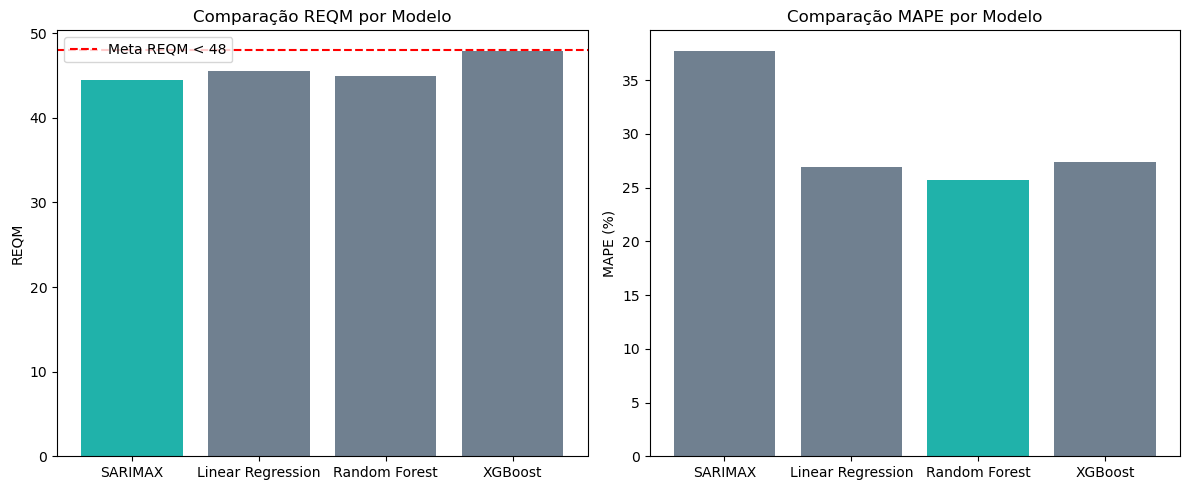

In [254]:
# gráfico de barras comparativo das métricas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# métrica: REQM
ax1.bar(df_resumo['Modelo'], [44.49, 45.59, 44.98, 47.95], 
        color=['lightseagreen', 'slategray', 'slategray', 'slategray'])
ax1.axhline(y=48, color='red', linestyle='--', label='Meta REQM < 48')
ax1.set_title('Comparação REQM por Modelo')
ax1.set_ylabel('REQM')
ax1.legend()

# MAPE
ax2.bar(df_resumo['Modelo'], [37.74, 26.87, 25.69, 27.41], 
        color=['slategray', 'slategray', 'lightseagreen', 'slategray'])
ax2.set_title('Comparação MAPE por Modelo')
ax2.set_ylabel('MAPE (%)')

plt.tight_layout()
plt.show()

## Conclusão do Projeto

Os 4 modelos desenvolvidos foram **aprovados** conforme o critério estabelecido (REQM < 48), demonstrando a eficácia das estratégias de feature engineering implementadas.

**Análise Comparativa dos Modelos**

*Ranking por REQM:*
1. 🥇 **SARIMAX**: 44.49 - Melhor precisão absoluta
2. 🥈 Random Forest: 44.98
3. 🥉 Linear Regression: 45.59
4. XGBoost: 47.95

*Ranking por MAPE:*
1. 🥇 **Random Forest**: 25.69% - Melhor acurácia relativa
2. 🥈 Linear Regression: 26.87%
3. 🥉 XGBoost: 27.41% 
4. SARIMAX: 37.74%

**Recomendação Final**

O **Random Forest** é recomendado para produção por apresentar:
- *Melhor equilíbrio* entre precisão (REQM: 44.98) e acurácia (MAPE: 25.69%)
- *Robustez* para capturar padrões não-lineares identificados na análise
- *Facilidade de interpretação* das features mais importantes
- *Estabilidade* sem necessidade de diferenciação ou normalização

**Insights de Negócio**
- *Sazonalidade Semanal*: Padrão de 168h confirmado (3 dias alta + 1 queda + 1 pico)
- *Tendência Crescente*: Demanda aumentou 27% em abril, sugerindo crescimento do negócio
- *Features Relevantes*: Lags de 1-7 dias e calendar features foram fundamentais para performance dos modelos
- *Volatilidade*: Agosto apresentou maior instabilidade (outliers 2.74%)